# Among Us player stats
Load player-season and optional voting summaries from `amongus.db`, then explore them with pandas and matplotlib.

In [1]:
from pathlib import Path
import sys

# Add the project root so imports work when Jupyter starts in this folder.
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / 'analyses' / 'loader.py').is_file():
        sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError('Could not locate the project root from ' + str(Path.cwd()))

from analyses.loader import load_player_stats, load_players_with_voting

players = load_player_stats()
players_with_voting = load_players_with_voting()
players.head()

,server_name,season,discord_id,username,source_file,combined_rank,combined_mmr,combined_played_pct,combined_wins,combined_losses,...,impostor_mmr,impostor_played_pct,impostor_wins,impostor_losses,impostor_games,impostor_win_pct,impostor_win_streak,impostor_win_streak_record,impostor_loss_streak,impostor_loss_streak_record
0,5UP Community,Season 1,666412766667472987,Ri,5UP1/Ri666412766667472987.html,117.0,834.0,100.0,6.0,5.0,...,823.0,27.0,1.0,2.0,3.0,33.0,1.0,1.0,0.0,2.0
1,5UP Community,Season 1,345830187964825600,za,5UP1/za345830187964825600.html,45.0,944.0,100.0,16.0,2.0,...,817.0,17.0,1.0,2.0,3.0,33.0,0.0,1.0,2.0,2.0
2,5UP Community,Season 1,607299023648325642,Avi,5UP1/Avi607299023648325642.html,151.0,802.0,100.0,8.0,4.0,...,700.0,17.0,0.0,2.0,2.0,0.0,0.0,0.0,2.0,2.0
3,5UP Community,Season 1,921617092594241566,cln,5UP1/cln921617092594241566.html,25.0,992.0,100.0,41.0,16.0,...,912.0,19.0,3.0,8.0,11.0,27.0,0.0,2.0,4.0,4.0
4,5UP Community,Season 1,988281593317720104,Deg,5UP1/Deg988281593317720104.html,307.0,459.0,100.0,10.0,7.0,...,492.0,18.0,2.0,1.0,3.0,67.0,0.0,2.0,1.0,1.0


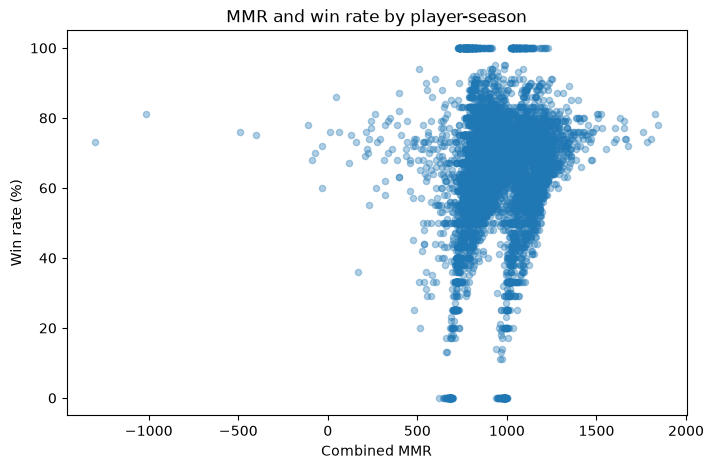

In [2]:
# Compare combined MMR and win rate; each point is one player-season.
plot_data = players.dropna(subset=['combined_mmr', 'combined_win_pct'])
ax = plot_data.plot.scatter(x='combined_mmr', y='combined_win_pct', alpha=0.35, figsize=(8, 5))
ax.set_xlabel('Combined MMR')
ax.set_ylabel('Win rate (%)')
ax.set_title('MMR and win rate by player-season');

Text(0.5, 1.0, 'Among Us League — Season 5')

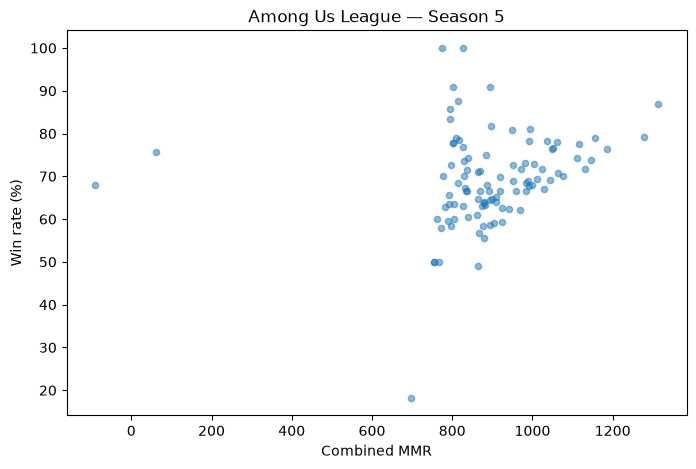

In [3]:
aul_s5 = players[
    (players["server_name"] == "Among Us League")
    & (players["season"] == "Season 5")
].copy()

aul_s5["win_rate"] = (
    100 * aul_s5["combined_wins"]
    / (aul_s5["combined_wins"] + aul_s5["combined_losses"])
)

aul_s5 = aul_s5.dropna(subset=["combined_mmr", "win_rate"])

ax = aul_s5.plot.scatter(
    x="combined_mmr",
    y="win_rate",
    alpha=0.5,
    figsize=(8, 5),
)
ax.set_xlabel("Combined MMR")
ax.set_ylabel("Win rate (%)")
ax.set_title("Among Us League — Season 5")